Генерация графиков сравнения методов...


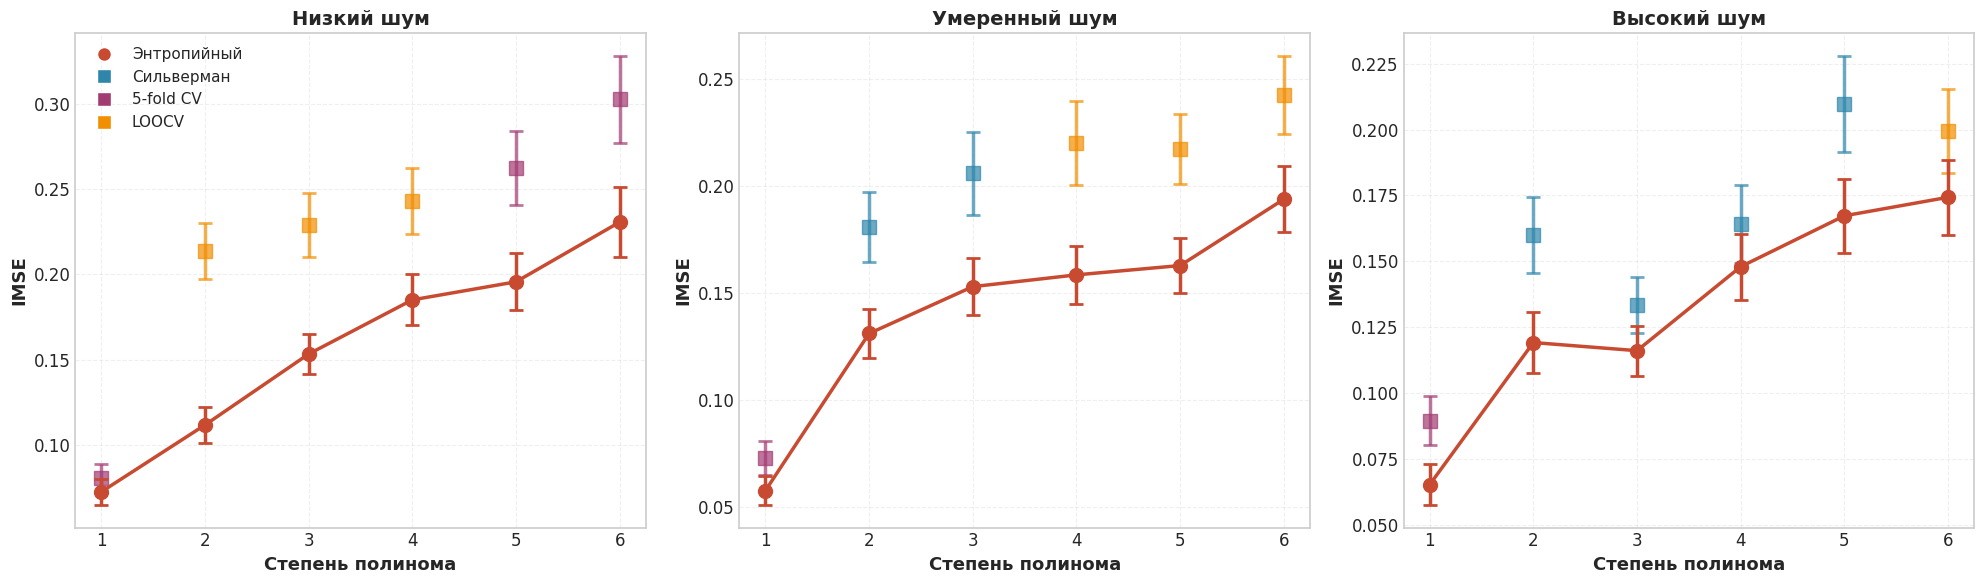

✓ IMSE vs степень полинома


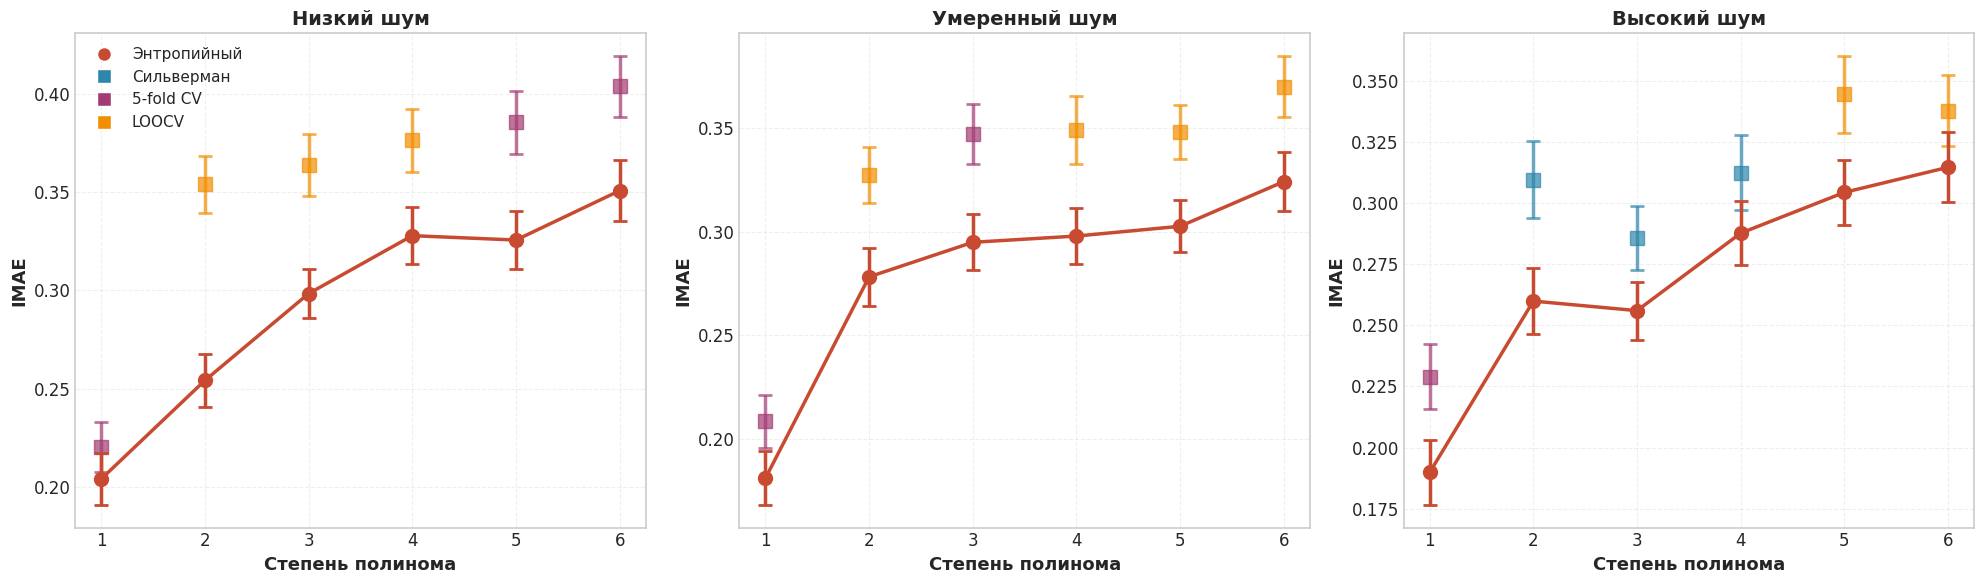

✓ IMAE vs степень полинома


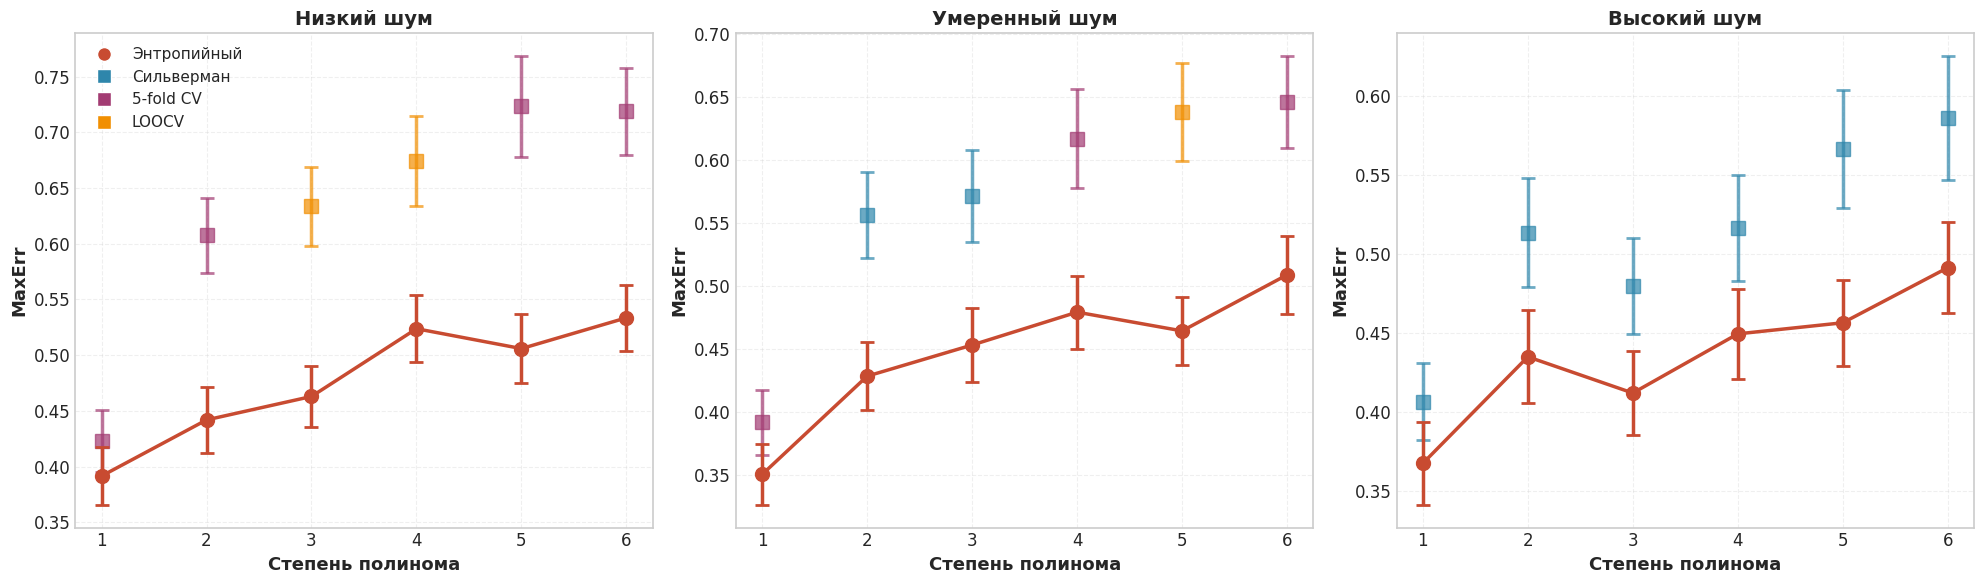

✓ MaxErr vs степень полинома


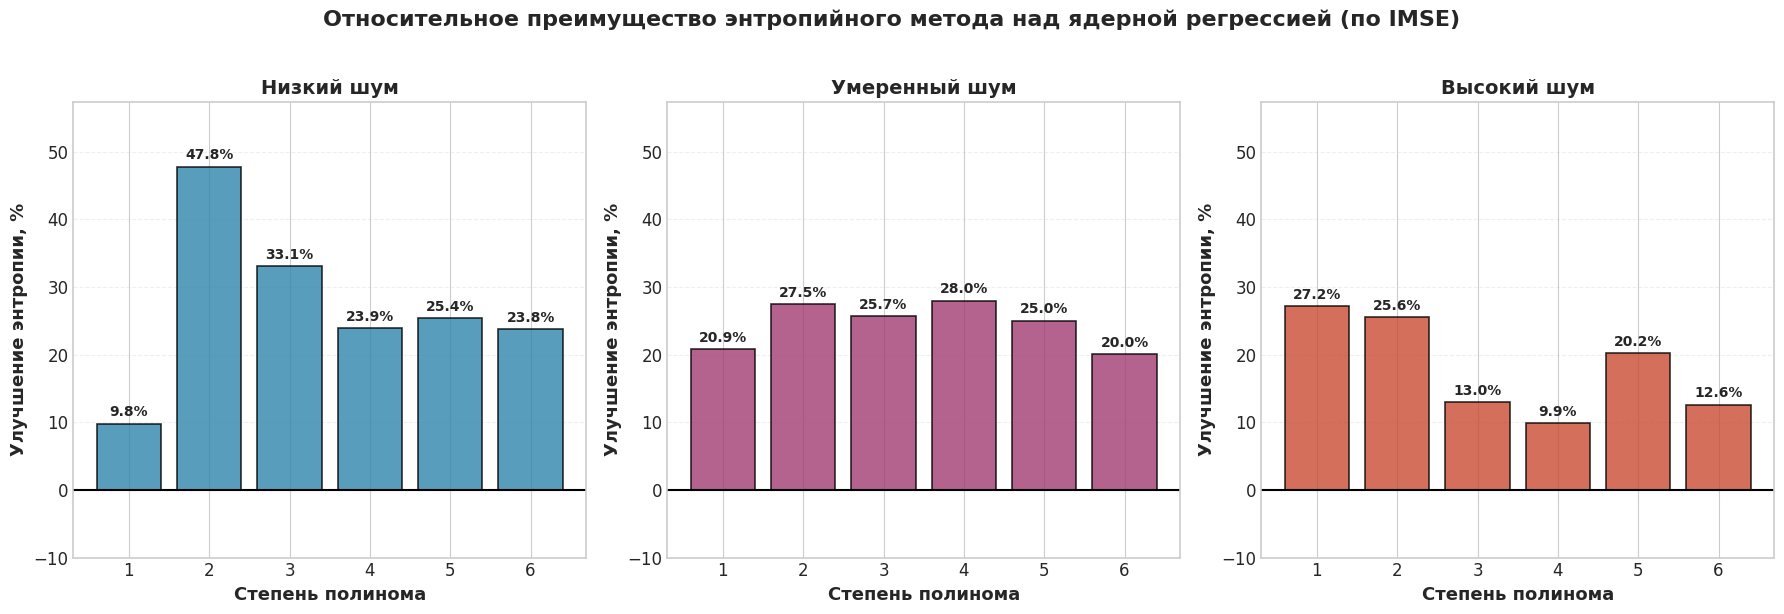

✓ Относительное улучшение (%)


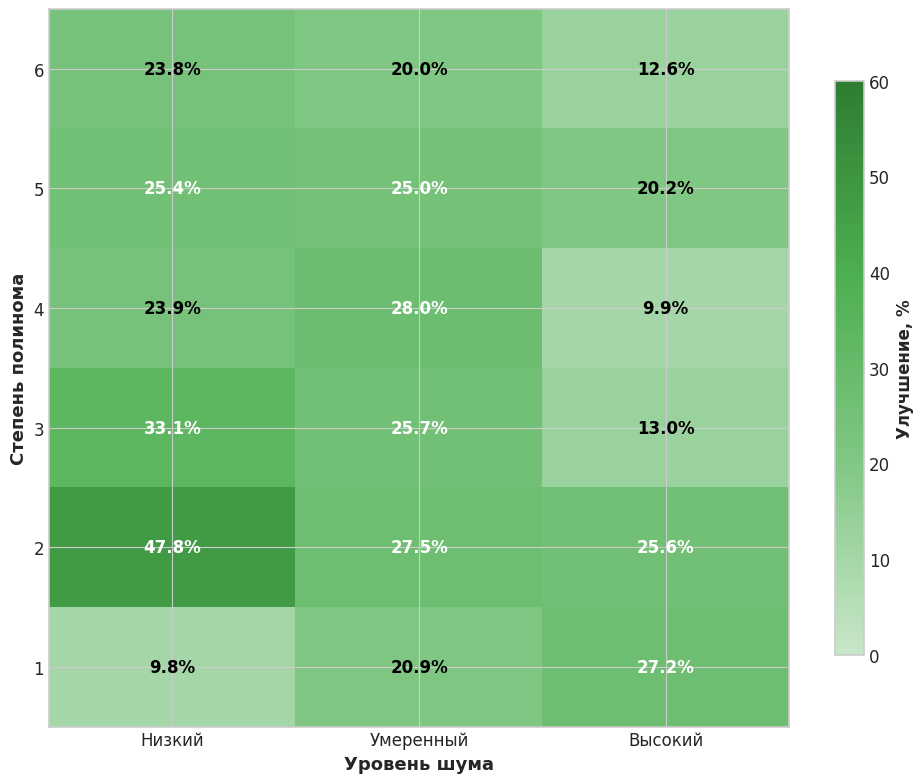


ТАБЛИЦА УЛУЧШЕНИЙ (%) - ДЛЯ ВЕРИФИКАЦИИ

Степень |  Низкий   |  Умеренный  |  Высокий
-------------------------------------------------------
   6    |    23.8%  |    20.0%   |    12.6%
   5    |    25.4%  |    25.0%   |    20.2%
   4    |    23.9%  |    28.0%   |     9.9%
   3    |    33.1%  |    25.7%   |    13.0%
   2    |    47.8%  |    27.5%   |    25.6%
   1    |     9.8%  |    20.9%   |    27.2%
✓ Тепловая карта преимуществ


C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\2522704483.py:474: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\2522704483.py:474: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\2522704483.py:474: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


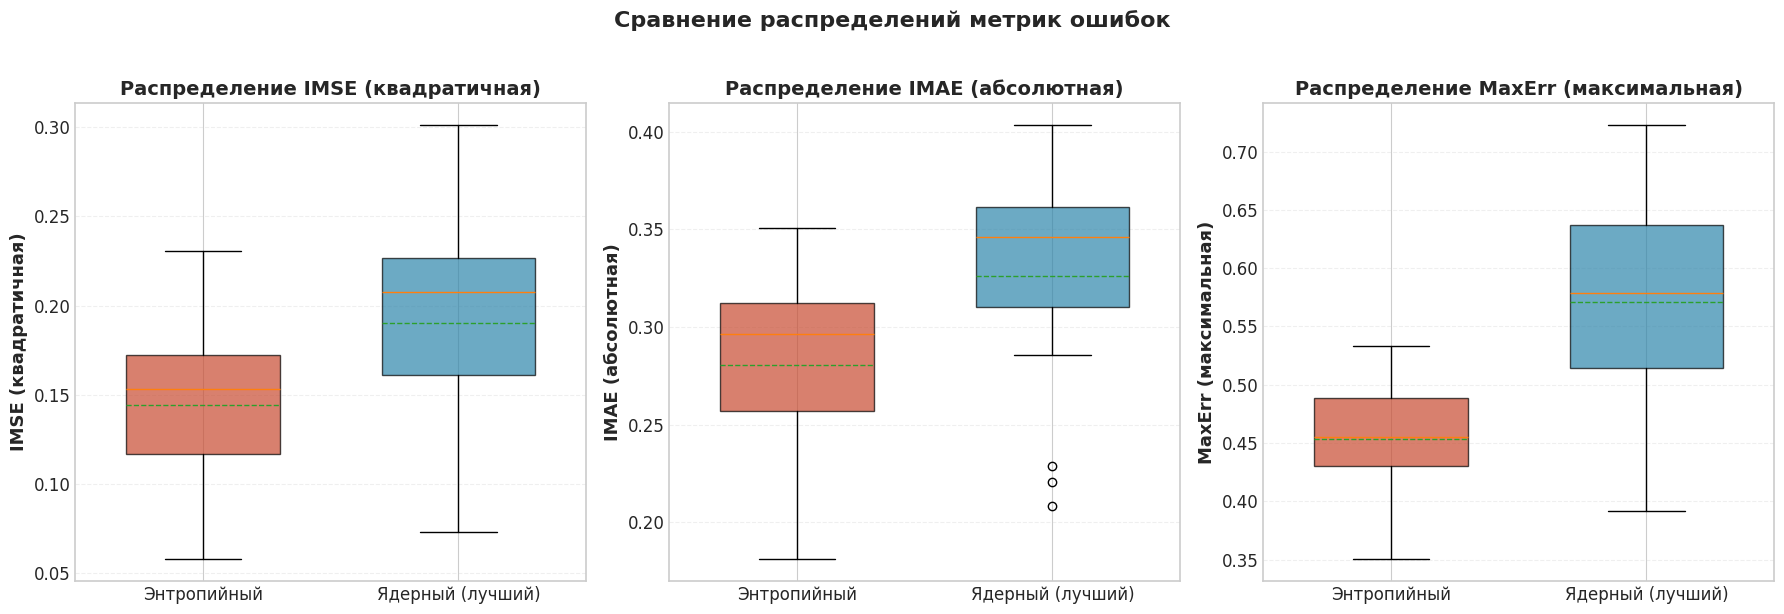

✓ Распределение метрик

Все графики сохранены в формате PNG (300 DPI)


In [13]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ: Сравнение энтропийного метода и ядерной регрессии
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# =============================================================================
# ЗАГРУЗКА ДАННЫХ
# =============================================================================

df_kernel = pd.read_csv('kernel_regression_results_clean.csv')
df_entropy = pd.read_csv('entropy_aggregated_clean.csv')

# =============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =============================================================================

def get_best_kernel_method(df_kernel, degree, noise_level, metric='imse'):
    """
    Возвращает лучший метод ядерной регрессии по критерию:
    min(metric_mean - 1.96 * metric_sem)
    """
    subset = df_kernel[(df_kernel['degree'] == degree) & 
                       (df_kernel['noise_level'] == noise_level)]
    
    # Вычисляем нижнюю границу доверительного интервала
    subset = subset.copy()
    subset[f'{metric}_lower'] = subset[f'{metric}_mean'] - 1.96 * subset[f'{metric}_sem']
    
    best_idx = subset[f'{metric}_lower'].idxmin()
    best_row = subset.loc[best_idx]
    
    return best_row['method'], best_row[f'{metric}_mean'], best_row[f'{metric}_sem']


def prepare_comparison_data(df_kernel, df_entropy, metric='imse'):
    """
    Подготавливает данные для сравнения: энтропия vs лучший ядерный метод
    """
    noise_levels = ['low', 'moderate', 'high']
    degrees = list(range(1, 7))
    
    results = []
    
    for noise in noise_levels:
        for deg in degrees:
            # Энтропия
            ent_row = df_entropy[(df_entropy['degree'] == deg) & 
                                 (df_entropy['noise_level'] == noise)]
            if len(ent_row) == 0:
                continue
            ent_row = ent_row.iloc[0]
            
            # Лучший ядерный метод
            best_method, kern_mean, kern_sem = get_best_kernel_method(
                df_kernel, deg, noise, metric=metric
            )
            
            results.append({
                'degree': deg,
                'noise_level': noise,
                'entropy_mean': ent_row[f'{metric}_mean'],
                'entropy_sem': ent_row[f'{metric}_sem'],
                'kernel_mean': kern_mean,
                'kernel_sem': kern_sem,
                'best_kernel_method': best_method
            })
    
    return pd.DataFrame(results)


def get_method_label(method):
    """Красивые названия методов"""
    labels = {
        'silverman': 'Сильверман',
        'cv': '5-fold CV',
        'loocv': 'LOOCV',
        'entropy': 'Энтропийный'
    }
    return labels.get(method, method)


def get_method_color(method):
    """Цвета для методов"""
    colors = {
        'silverman': '#2E86AB',
        'cv': '#A23B72',
        'loocv': '#F18F01',
        'entropy': '#C84B31'
    }
    return colors.get(method, '#333333')

# =============================================================================
# ГРАФИК 1: IMSE vs Степень полинома (по уровням шума)
# =============================================================================

def plot_imse_by_degree():
    """
    График: зависимость средней квадратичной ошибки от сложности модели
    Энтропия vs Лучший метод ядерной регрессии
    """
    df_comp = prepare_comparison_data(df_kernel, df_entropy, metric='imse')
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    noise_levels = ['low', 'moderate', 'high']
    noise_labels = ['Низкий шум', 'Умеренный шум', 'Высокий шум']
    
    # Цвета для методов
    entropy_color = '#C84B31'
    kernel_colors = {'silverman': '#2E86AB', 'cv': '#A23B72', 'loocv': '#F18F01'}
    
    for ax_idx, noise in enumerate(noise_levels):
        ax = axes[ax_idx]
        df_noise = df_comp[df_comp['noise_level'] == noise]
        
        # Энтропия
        ax.errorbar(df_noise['degree'], df_noise['entropy_mean'], 
                   yerr=1.96 * df_noise['entropy_sem'],
                   marker='o', markersize=10, linewidth=2.5,
                   label='Энтропийный метод', color=entropy_color,
                   capsize=5, capthick=2, zorder=5)
        
        # Ядерная регрессия (лучший метод) - рисуем по точкам с разными цветами
        for idx, row in df_noise.iterrows():
            method = row['best_kernel_method']
            color = kernel_colors.get(method, '#333333')
            
            ax.errorbar(row['degree'], row['kernel_mean'],
                       yerr=1.96 * row['kernel_sem'],
                       marker='s', markersize=10, linewidth=2.5,
                       label=None, color=color,
                       capsize=5, capthick=2, alpha=0.7)
        
        # Легенда для методов ядра (показать один раз)
        if ax_idx == 0:
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor=entropy_color, 
                      markersize=10, label='Энтропийный'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#2E86AB', 
                      markersize=10, label='Сильверман'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#A23B72', 
                      markersize=10, label='5-fold CV'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#F18F01', 
                      markersize=10, label='LOOCV'),
            ]
            ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
        
        ax.set_xlabel('Степень полинома', fontsize=13, fontweight='bold')
        ax.set_ylabel('IMSE', fontsize=13, fontweight='bold')
        ax.set_title(noise_labels[ax_idx], fontsize=14, fontweight='bold')
        ax.set_xticks([1, 2, 3, 4, 5, 6])
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
        ax.set_axisbelow(True)
    
    # plt.suptitle('Сравнение методов регрессии: IMSE в зависимости от степени полинома', 
    #             fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('imse_vs_degree_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_comp

# =============================================================================
# ГРАФИК 2: IMAE vs Степень полинома (по уровням шума)
# =============================================================================

def plot_imae_by_degree():
    """
    График: зависимость средней абсолютной ошибки от сложности модели
    """
    df_comp = prepare_comparison_data(df_kernel, df_entropy, metric='imae')
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    noise_levels = ['low', 'moderate', 'high']
    noise_labels = ['Низкий шум', 'Умеренный шум', 'Высокий шум']
    
    entropy_color = '#C84B31'
    kernel_colors = {'silverman': '#2E86AB', 'cv': '#A23B72', 'loocv': '#F18F01'}
    
    for ax_idx, noise in enumerate(noise_levels):
        ax = axes[ax_idx]
        df_noise = df_comp[df_comp['noise_level'] == noise]
        
        # Энтропия
        ax.errorbar(df_noise['degree'], df_noise['entropy_mean'], 
                   yerr=1.96 * df_noise['entropy_sem'],
                   marker='o', markersize=10, linewidth=2.5,
                   label='Энтропийный метод' if ax_idx == 0 else '', 
                   color=entropy_color,
                   capsize=5, capthick=2, zorder=5)
        
        # Ядерная регрессия
        for idx, row in df_noise.iterrows():
            method = row['best_kernel_method']
            color = kernel_colors.get(method, '#333333')
            
            ax.errorbar(row['degree'], row['kernel_mean'],
                       yerr=1.96 * row['kernel_sem'],
                       marker='s', markersize=10, linewidth=2.5,
                       label=None, color=color,
                       capsize=5, capthick=2, alpha=0.7)
        
        if ax_idx == 0:
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor=entropy_color, 
                      markersize=10, label='Энтропийный'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#2E86AB', 
                      markersize=10, label='Сильверман'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#A23B72', 
                      markersize=10, label='5-fold CV'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#F18F01', 
                      markersize=10, label='LOOCV'),
            ]
            ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
        
        ax.set_xlabel('Степень полинома', fontsize=13, fontweight='bold')
        ax.set_ylabel('IMAE', fontsize=13, fontweight='bold')
        ax.set_title(noise_labels[ax_idx], fontsize=14, fontweight='bold')
        ax.set_xticks([1, 2, 3, 4, 5, 6])
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
        ax.set_axisbelow(True)
    
    # plt.suptitle('Сравнение методов регрессии: IMAE в зависимости от степени полинома', 
    #             fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('imae_vs_degree_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# ГРАФИК 3: Максимальная ошибка (MaxErr) vs Степень полинома
# =============================================================================

def plot_maxerr_by_degree():
    """
    График: зависимость максимальной ошибки от сложности модели
    """
    df_comp = prepare_comparison_data(df_kernel, df_entropy, metric='maxerr')
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    noise_levels = ['low', 'moderate', 'high']
    noise_labels = ['Низкий шум', 'Умеренный шум', 'Высокий шум']
    
    entropy_color = '#C84B31'
    kernel_colors = {'silverman': '#2E86AB', 'cv': '#A23B72', 'loocv': '#F18F01'}
    
    for ax_idx, noise in enumerate(noise_levels):
        ax = axes[ax_idx]
        df_noise = df_comp[df_comp['noise_level'] == noise]
        
        # Энтропия
        ax.errorbar(df_noise['degree'], df_noise['entropy_mean'], 
                   yerr=1.96 * df_noise['entropy_sem'],
                   marker='o', markersize=10, linewidth=2.5,
                   label='Энтропийный метод' if ax_idx == 0 else '', 
                   color=entropy_color,
                   capsize=5, capthick=2, zorder=5)
        
        # Ядерная регрессия
        for idx, row in df_noise.iterrows():
            method = row['best_kernel_method']
            color = kernel_colors.get(method, '#333333')
            
            ax.errorbar(row['degree'], row['kernel_mean'],
                       yerr=1.96 * row['kernel_sem'],
                       marker='s', markersize=10, linewidth=2.5,
                       label=None, color=color,
                       capsize=5, capthick=2, alpha=0.7)
        
        if ax_idx == 0:
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', markerfacecolor=entropy_color, 
                      markersize=10, label='Энтропийный'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#2E86AB', 
                      markersize=10, label='Сильверман'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#A23B72', 
                      markersize=10, label='5-fold CV'),
                Line2D([0], [0], marker='s', color='w', markerfacecolor='#F18F01', 
                      markersize=10, label='LOOCV'),
            ]
            ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)
        
        ax.set_xlabel('Степень полинома', fontsize=13, fontweight='bold')
        ax.set_ylabel('MaxErr', fontsize=13, fontweight='bold')
        ax.set_title(noise_labels[ax_idx], fontsize=14, fontweight='bold')
        ax.set_xticks([1, 2, 3, 4, 5, 6])
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
        ax.set_axisbelow(True)
    
    # plt.suptitle('Сравнение методов регрессии: Максимальная ошибка', 
    #             fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('maxerr_vs_degree_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# ГРАФИК 4: Относительное улучшение энтропийного метода (%)
# =============================================================================

def plot_relative_improvement():
    """
    График: насколько энтропийный метод лучше ядерного (в процентах)
    Positive = энтропия лучше
    """
    df_comp = prepare_comparison_data(df_kernel, df_entropy, metric='imse')
    
    # Вычисляем относительное улучшение
    df_comp['improvement_pct'] = (
        (df_comp['kernel_mean'] - df_comp['entropy_mean']) / df_comp['kernel_mean'] * 100
    )
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    noise_levels = ['low', 'moderate', 'high']
    noise_labels = ['Низкий шум', 'Умеренный шум', 'Высокий шум']
    colors = ['#2E86AB', '#A23B72', '#C84B31']
    
    for ax_idx, noise in enumerate(noise_levels):
        ax = axes[ax_idx]
        df_noise = df_comp[df_comp['noise_level'] == noise]
        
        # Столбчатая диаграмма
        bars = ax.bar(df_noise['degree'], df_noise['improvement_pct'],
                     color=colors[ax_idx], edgecolor='black', linewidth=1.2, alpha=0.8)
        
        # Линия нуля
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
        
        # Подписи на столбцах
        for bar, val in zip(bars, df_noise['improvement_pct'].values):
            height = bar.get_height()
            ax.annotate(f'{val:.1f}%',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3 if height > 0 else -15),
                       textcoords="offset points",
                       ha='center', va='bottom' if height > 0 else 'top',
                       fontsize=10, fontweight='bold')
        
        ax.set_xlabel('Степень полинома', fontsize=13, fontweight='bold')
        ax.set_ylabel('Улучшение энтропии, %', fontsize=13, fontweight='bold')
        ax.set_title(noise_labels[ax_idx], fontsize=14, fontweight='bold')
        ax.set_xticks([1, 2, 3, 4, 5, 6])
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, axis='y')
        ax.set_axisbelow(True)
        ax.set_ylim(-10, max(df_comp['improvement_pct']) * 1.2)
    
    plt.suptitle('Относительное преимущество энтропийного метода над ядерной регрессией (по IMSE)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('relative_improvement.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# ГРАФИК 5: Тепловая карта преимуществ (сводная) - ИСПРАВЛЕННАЯ
# =============================================================================

def plot_heatmap_summary():
    """
    Тепловая карта: преимущество энтропии по всем комбинациям степень×шум
    🟢 Цветовая гамма: светло-зелёный → тёмно-зелёный (все значения = улучшение)
    """
    df_comp = prepare_comparison_data(df_kernel, df_entropy, metric='imse')
    
    # Вычисляем относительное улучшение
    df_comp['improvement_pct'] = (
        (df_comp['kernel_mean'] - df_comp['entropy_mean']) / df_comp['kernel_mean'] * 100
    )
    
    # Pivot для тепловой карты
    heatmap_data = df_comp.pivot(index='degree', columns='noise_level', values='improvement_pct')
    heatmap_data = heatmap_data.reindex(index=[6, 5, 4, 3, 2, 1])  # Reverse order for degree
    
    # 🔧 ИСПРАВЛЕНИЕ: Явно указываем порядок столбцов по уровню шума
    heatmap_data = heatmap_data.reindex(columns=['low', 'moderate', 'high'])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 🟢 Custom colormap: СВЕТЛО-ЗЕЛЁНЫЙ → ТЁМНО-ЗЕЛЁНЫЙ
    # Все значения положительные (улучшение), поэтому красный не нужен
    from matplotlib.colors import LinearSegmentedColormap
    
    cmap = LinearSegmentedColormap.from_list(
        'green_gradient', 
        ['#C8E6C9', '#81C784', '#4CAF50', '#2E7D32'],  # Светло-зелёный → Тёмно-зелёный
        N=100
    )
    
    # Тепловая карта
    im = ax.imshow(heatmap_data.values, cmap=cmap, aspect='auto', vmin=0, vmax=60)
    
    # Подписи значений
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.values[i, j]
            # Белый текст для тёмных ячеек (высокое улучшение), чёрный для светлых
            text_color = 'white' if val > 25 else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', 
                   fontsize=12, fontweight='bold', color=text_color)
    
    # Оси
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_xticklabels(['Низкий', 'Умеренный', 'Высокий'], fontsize=12)
    ax.set_yticklabels(heatmap_data.index, fontsize=12)
    ax.set_xlabel('Уровень шума', fontsize=13, fontweight='bold')
    ax.set_ylabel('Степень полинома', fontsize=13, fontweight='bold')
    # ax.set_title('Преимущество энтропийного метода над ядерной регрессией (по IMSE, %)\n🟢 Зелёный градиент: светлый = малое улучшение, тёмный = большое', 
    #             fontsize=14, fontweight='bold', pad=15)
    
    # Цветовая шкала
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Улучшение, %', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('heatmap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 🔍 Для верификации: выводим таблицу значений
    print("\n" + "=" * 70)
    print("ТАБЛИЦА УЛУЧШЕНИЙ (%) - ДЛЯ ВЕРИФИКАЦИИ")
    print("=" * 70)
    print("\nСтепень |  Низкий   |  Умеренный  |  Высокий")
    print("-" * 55)
    for degree in heatmap_data.index:
        row = heatmap_data.loc[degree]
        print(f"   {degree}    |  {row['low']:6.1f}%  |  {row['moderate']:6.1f}%   |  {row['high']:6.1f}%")
    print("=" * 70)
    
# =============================================================================
# ГРАФИК 6: Box plot распределения ошибок (сводный по всем степеням)
# =============================================================================

def plot_metric_distribution():
    """
    Распределение метрик по методам (агрегировано по всем степеням и шумам)
    """
    # Агрегируем данные
    entropy_imse = df_entropy['imse_mean'].values
    kernel_imse = df_kernel.groupby(['degree', 'noise_level'])['imse_mean'].min().values
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    metrics = ['imse', 'imae', 'maxerr']
    metric_labels = ['IMSE (квадратичная)', 'IMAE (абсолютная)', 'MaxErr (максимальная)']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        ent_values = df_entropy[f'{metric}_mean'].values
        kern_values = df_kernel.groupby(['degree', 'noise_level'])[f'{metric}_mean'].min().values
        
        data = [ent_values, kern_values]
        labels = ['Энтропийный', 'Ядерный (лучший)']
        colors = ['#C84B31', '#2E86AB']
        
        bp = ax.boxplot(data, labels=labels, patch_artist=True,
                       widths=0.6, showmeans=True, meanline=True)
        
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel(metric_labels[idx], fontsize=13, fontweight='bold')
        ax.set_title(f'Распределение {metric_labels[idx]}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_axisbelow(True)
    
    plt.suptitle('Сравнение распределений метрик ошибок', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('metric_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# ЗАПУСК ВСЕХ ГРАФИКОВ
# =============================================================================

if __name__ == '__main__':
    print("Генерация графиков сравнения методов...")
    
    plot_imse_by_degree()
    print("✓ IMSE vs степень полинома")
    
    plot_imae_by_degree()
    print("✓ IMAE vs степень полинома")
    
    plot_maxerr_by_degree()
    print("✓ MaxErr vs степень полинома")
    
    plot_relative_improvement()
    print("✓ Относительное улучшение (%)")
    
    plot_heatmap_summary()
    print("✓ Тепловая карта преимуществ")
    
    plot_metric_distribution()
    print("✓ Распределение метрик")
    
    print("\nВсе графики сохранены в формате PNG (300 DPI)")


🔬 Запуск статистического анализа (ИСПРАВЛЕННАЯ ВЕРСИЯ)...

ОТЛАДКА: Проверка расчётов t-test

--- Степень 1, шум: low ---
Энтропия: mean=0.072406, SEM=0.003945, n=282
Ядро (cv): mean=0.080281, SEM=0.004309, n=264
Разность средних: 0.007875
SE разности: 0.005842
t-статистика: 1.3480
Степени свободы: 536.1
p-value: 0.178216
Значимо (α=0.05): НЕТ ✗

--- Степень 1, шум: moderate ---
Энтропия: mean=0.057842, SEM=0.003464, n=273
Ядро (cv): mean=0.073096, SEM=0.004100, n=267
Разность средних: 0.015254
SE разности: 0.005368
t-статистика: 2.8419
Степени свободы: 521.4
p-value: 0.004660
Значимо (α=0.05): ДА ✓

--- Степень 1, шум: high ---
Энтропия: mean=0.065123, SEM=0.003954, n=274
Ядро (cv): mean=0.089447, SEM=0.004796, n=268
Разность средних: 0.024325
SE разности: 0.006216
t-статистика: 3.9134
Степени свободы: 518.9
p-value: 0.000103
Значимо (α=0.05): ДА ✓
СТАТИСТИЧЕСКИЙ АНАЛИЗ: T-TEST (Welch's t-test, ИСПРАВЛЕННЫЙ)
Метрика: IMSE

📊 ОБЩАЯ СТАТИСТИКА:
   Всего сравнений: 18
   Значимых различи

C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:241: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:241: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:242: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('pvalue_heatmap.png', dpi=300, bbox_inches='tight')
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:242: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('pvalue_heatmap.png', dpi=300, bbox_inches='tight')
c:\Users\Dima\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

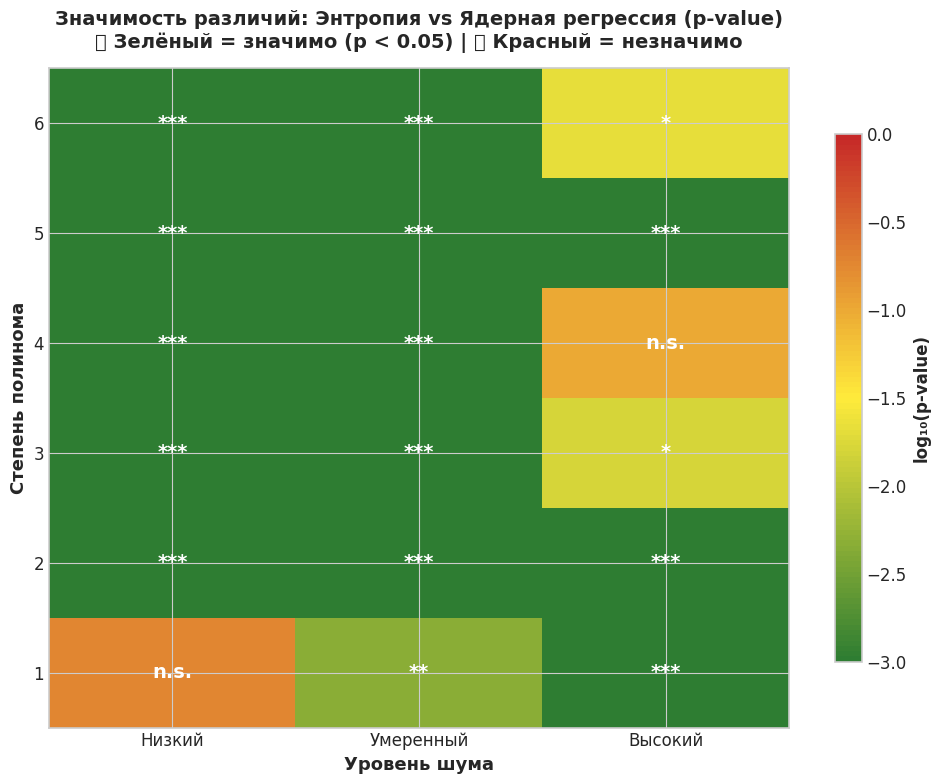

C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:308: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:308: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:309: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('tstatistic_by_degree.png', dpi=300, bbox_inches='tight')
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1182429557.py:309: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('tstatistic_by_degree.png', dpi=300, bbox_inches='tight')


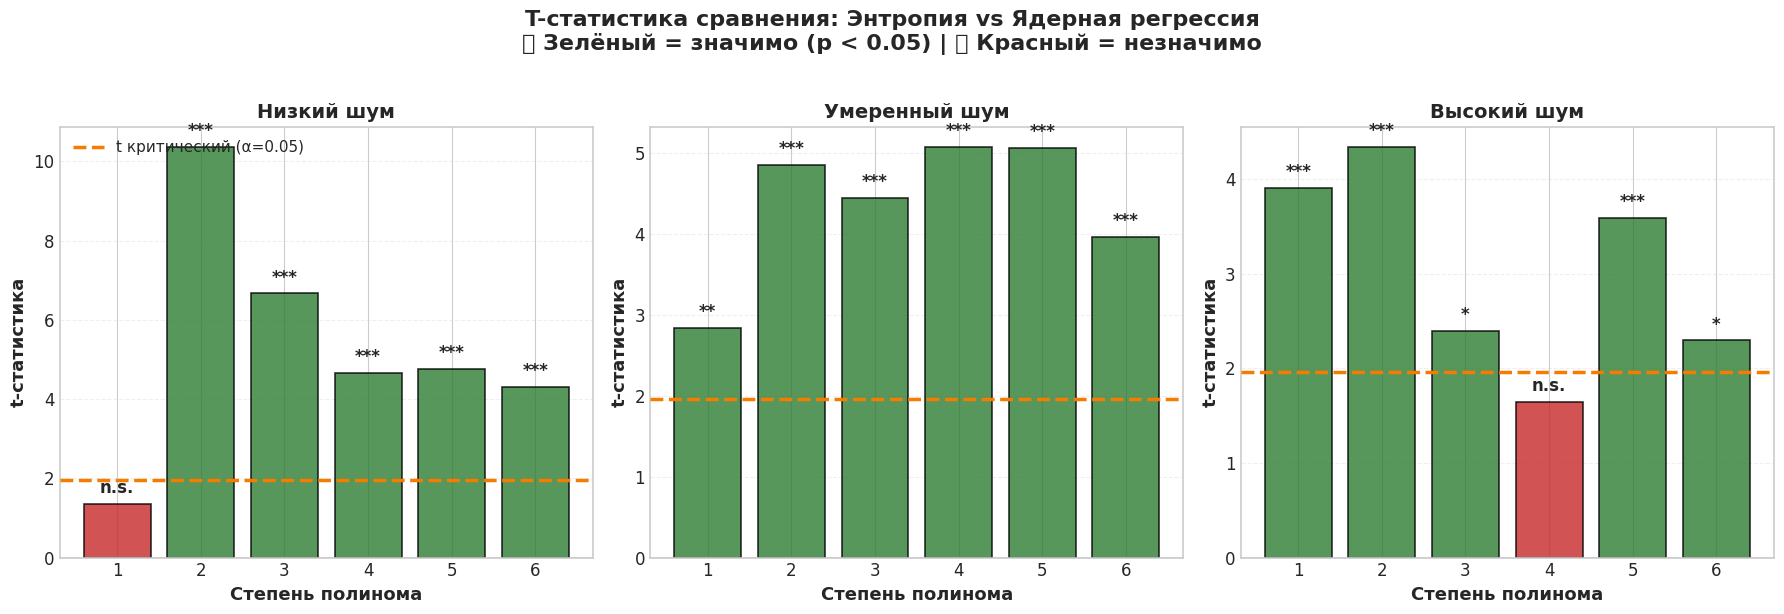


✅ Все файлы сохранены!

📁 Созданные файлы:
   - statistical_test_table_fixed.csv
   - statistical_test_imse_fixed.xlsx
   - pvalue_heatmap_fixed.png
   - tstatistic_by_degree_fixed.png


In [8]:
# =============================================================================
# СТАТИСТИЧЕСКИЙ АНАЛИЗ: T-TEST (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# =============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import MaxNLocator

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# =============================================================================
# ЗАГРУЗКА ДАННЫХ
# =============================================================================

df_kernel = pd.read_csv('kernel_regression_results_clean.csv')
df_entropy = pd.read_csv('entropy_aggregated_clean.csv')

# =============================================================================
# ИСПРАВЛЕННЫЕ ФУНКЦИИ ДЛЯ T-TEST
# =============================================================================

def get_best_kernel_method(df_kernel, degree, noise_level, metric='imse'):
    """
    Возвращает лучший метод ядерной регрессии по критерию:
    min(metric_mean - 1.96 * metric_sem)
    """
    subset = df_kernel[(df_kernel['degree'] == degree) & 
                       (df_kernel['noise_level'] == noise_level)]
    
    subset = subset.copy()
    subset[f'{metric}_lower'] = subset[f'{metric}_mean'] - 1.96 * subset[f'{metric}_sem']
    
    best_idx = subset[f'{metric}_lower'].idxmin()
    best_row = subset.loc[best_idx]
    
    return best_row


def calculate_welch_ttest(mean1, sem1, n1, mean2, sem2, n2):
    """
    Расчёт Welch's t-test (ИСПРАВЛЕННАЯ ВЕРСИЯ)
    
    SEM = std / sqrt(n), поэтому:
    - std1 = sem1 * sqrt(n1)
    - std2 = sem2 * sqrt(n2)
    - SE разности средних = sqrt(sem1^2 + sem2^2)  [это уже правильно!]
    
    Args:
        mean1, sem1, n1: статистики первой выборки (энтропия)
        mean2, sem2, n2: статистики второй выборки (ядро)
    
    Returns:
        t_stat, p_value, df, significant, highly_significant
    """
    # Стандартная ошибка разности средних (SEM уже включает sqrt(n))
    se_diff = np.sqrt(sem1**2 + sem2**2)
    
    # T-статистика
    t_stat = (mean2 - mean1) / se_diff  # Положительное = энтропия лучше
    
    # Степени свободы по формуле Велча-Сатертуэйта
    # Используем SEM напрямую, т.к. var(mean) = SEM^2
    df = (sem1**2 + sem2**2)**2 / (sem1**4/(n1-1) + sem2**4/(n2-1))
    
    # Двусторонний p-value
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df))
    
    # Уровень значимости
    significant = p_value < 0.05
    highly_significant = p_value < 0.01
    
    return t_stat, p_value, df, significant, highly_significant


def perform_all_ttests(df_kernel, df_entropy, metric='imse'):
    """
    Выполняет t-test для всех комбинаций степень×шум
    """
    noise_levels = ['low', 'moderate', 'high']
    degrees = list(range(1, 7))
    
    results = []
    
    for noise in noise_levels:
        for deg in degrees:
            # Энтропия
            ent_row = df_entropy[(df_entropy['degree'] == deg) & 
                                 (df_entropy['noise_level'] == noise)]
            if len(ent_row) == 0:
                continue
            ent_row = ent_row.iloc[0]
            
            # Лучший ядерный метод
            kern_row = get_best_kernel_method(df_kernel, deg, noise, metric=metric)
            
            # T-test
            t_stat, p_value, df_welch, sig, highly_sig = calculate_welch_ttest(
                mean1=ent_row[f'{metric}_mean'],
                sem1=ent_row[f'{metric}_sem'],
                n1=ent_row['n_used'],
                mean2=kern_row[f'{metric}_mean'],
                sem2=kern_row[f'{metric}_sem'],
                n2=kern_row['n_used']
            )
            
            # Эффект (Cohen's d)
            # pooled_std = sqrt(((n1-1)*std1^2 + (n2-1)*std2^2) / (n1+n2-2))
            std1 = ent_row[f'{metric}_sem'] * np.sqrt(ent_row['n_used'])
            std2 = kern_row[f'{metric}_sem'] * np.sqrt(kern_row['n_used'])
            pooled_std = np.sqrt(((ent_row['n_used']-1)*std1**2 + 
                                  (kern_row['n_used']-1)*std2**2) / 
                                 (ent_row['n_used'] + kern_row['n_used'] - 2))
            cohens_d = (kern_row[f'{metric}_mean'] - ent_row[f'{metric}_mean']) / pooled_std
            
            results.append({
                'degree': deg,
                'noise_level': noise,
                'entropy_mean': ent_row[f'{metric}_mean'],
                'kernel_mean': kern_row[f'{metric}_mean'],
                'kernel_method': kern_row['method'],
                't_statistic': t_stat,
                'p_value': p_value,
                'df': df_welch,
                'significant': sig,
                'highly_significant': highly_sig,
                'cohens_d': cohens_d,
                'improvement_pct': (kern_row[f'{metric}_mean'] - ent_row[f'{metric}_mean']) / kern_row[f'{metric}_mean'] * 100
            })
    
    return pd.DataFrame(results)


# =============================================================================
# ПРОВЕРКА РАСЧЁТОВ (ДЛЯ ОТЛАДКИ)
# =============================================================================

def print_debug_calculations(df_kernel, df_entropy):
    """
    Выводит подробные расчёты для проверки
    """
    print("=" * 80)
    print("ОТЛАДКА: Проверка расчётов t-test")
    print("=" * 80)
    
    for noise in ['low', 'moderate', 'high']:
        print(f"\n--- Степень 1, шум: {noise} ---")
        
        ent_row = df_entropy[(df_entropy['degree'] == 1) & 
                             (df_entropy['noise_level'] == noise)].iloc[0]
        kern_row = get_best_kernel_method(df_kernel, 1, noise, 'imse')
        
        mean1, sem1, n1 = ent_row['imse_mean'], ent_row['imse_sem'], ent_row['n_used']
        mean2, sem2, n2 = kern_row['imse_mean'], kern_row['imse_sem'], kern_row['n_used']
        
        se_diff = np.sqrt(sem1**2 + sem2**2)
        t_stat = (mean2 - mean1) / se_diff
        df = (sem1**2 + sem2**2)**2 / (sem1**4/(n1-1) + sem2**4/(n2-1))
        p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df))
        
        print(f"Энтропия: mean={mean1:.6f}, SEM={sem1:.6f}, n={n1}")
        print(f"Ядро ({kern_row['method']}): mean={mean2:.6f}, SEM={sem2:.6f}, n={n2}")
        print(f"Разность средних: {mean2 - mean1:.6f}")
        print(f"SE разности: {se_diff:.6f}")
        print(f"t-статистика: {t_stat:.4f}")
        print(f"Степени свободы: {df:.1f}")
        print(f"p-value: {p_value:.6f}")
        print(f"Значимо (α=0.05): {'ДА ✓' if p_value < 0.05 else 'НЕТ ✗'}")


# =============================================================================
# ВИЗУАЛИЗАЦИЯ: ТЕПЛОВАЯ КАРТА P-VALUE (ИСПРАВЛЕННАЯ)
# =============================================================================

def plot_pvalue_heatmap(df_results, metric='imse'):
    """
    Тепловая карта p-values по комбинациям степень×шум
    🟢 Зелёный = значимо (p < 0.05)
    🔴 Красный = незначимо (p >= 0.05)
    """
    # Pivot для тепловой карты
    pivot_data = df_results.pivot(index='degree', columns='noise_level', values='p_value')
    pivot_data = pivot_data.reindex(index=[6, 5, 4, 3, 2, 1])  # Reverse order for degree
    
    # 🔧 ИСПРАВЛЕНИЕ: Явно указываем порядок столбцов по уровню шума
    pivot_data = pivot_data.reindex(columns=['low', 'moderate', 'high'])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Custom colormap: ЗЕЛЁНЫЙ (значимо) -> ЖЁЛТЫЙ (погранично) -> КРАСНЫЙ (незначимо)
    cmap = colors.LinearSegmentedColormap.from_list(
        'significance', 
        ['#2E7D32', '#FFEB3B', '#C62828'],  # Зелёный -> Жёлтый -> Красный
        N=100
    )
    
    # Тепловая карта с логарифмической шкалой
    im = ax.imshow(np.log10(pivot_data.values + 1e-10), 
                   aspect='auto', cmap=cmap, vmin=np.log10(0.001), vmax=np.log10(1.0))
    
    # Подписи значений
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            val = pivot_data.values[i, j]
            if val < 0.001:
                text = '***'
                color = 'white'
            elif val < 0.01:
                text = '**'
                color = 'white'
            elif val < 0.05:
                text = '*'
                color = 'white'
            else:
                text = 'n.s.'
                color = 'white'
            
            ax.text(j, i, text, ha='center', va='center', 
                   fontsize=14, fontweight='bold', color=color)
    
    # Оси
    ax.set_xticks(range(len(pivot_data.columns)))
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_xticklabels(['Низкий', 'Умеренный', 'Высокий'], fontsize=12)
    ax.set_yticklabels(pivot_data.index, fontsize=12)
    ax.set_xlabel('Уровень шума', fontsize=13, fontweight='bold')
    ax.set_ylabel('Степень полинома', fontsize=13, fontweight='bold')
    ax.set_title('Значимость различий: Энтропия vs Ядерная регрессия (p-value)\n🟢 Зелёный = значимо (p < 0.05) | 🔴 Красный = незначимо', 
                fontsize=14, fontweight='bold', pad=15)
    
    # Цветовая шкала
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('log₁₀(p-value)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('pvalue_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# ГРАФИК: T-STATISTIC ПО СТЕПЕНЯМ (ИСПРАВЛЕННЫЙ)
# =============================================================================

def plot_tstatistic_by_degree(df_results, metric='imse'):
    """
    График t-статистики по степеням полинома
    🟢 Зелёный = значимо, 🔴 Красный = незначимо
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 🔧 ИСПРАВЛЕНИЕ: Явный порядок уровней шума
    noise_levels = ['low', 'moderate', 'high']
    noise_labels = ['Низкий шум', 'Умеренный шум', 'Высокий шум']
    
    for ax_idx, noise in enumerate(noise_levels):
        ax = axes[ax_idx]
        df_noise = df_results[df_results['noise_level'] == noise]
        
        # Столбцы t-статистики
        bar_colors = ['#2E7D32' if s else '#C62828' for s in df_noise['significant']]
        
        bars = ax.bar(df_noise['degree'], df_noise['t_statistic'],
                     color=bar_colors,
                     edgecolor='black', linewidth=1.2, alpha=0.8)
        
        # Линия значимости (t ≈ 2 для больших df)
        ax.axhline(y=1.96, color='#F57C00', linestyle='--', linewidth=2.5, 
                  label='t критический (α=0.05)', zorder=5)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        
        # Подписи
        for bar, pval in zip(bars, df_noise['p_value'].values):
            height = bar.get_height()
            if pval < 0.001:
                sig_text = '***'
            elif pval < 0.01:
                sig_text = '**'
            elif pval < 0.05:
                sig_text = '*'
            else:
                sig_text = 'n.s.'
            
            ax.annotate(sig_text,
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5),
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=12, fontweight='bold')
        
        ax.set_xlabel('Степень полинома', fontsize=13, fontweight='bold')
        ax.set_ylabel('t-статистика', fontsize=13, fontweight='bold')
        ax.set_title(noise_labels[ax_idx], fontsize=14, fontweight='bold')
        ax.set_xticks([1, 2, 3, 4, 5, 6])
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_axisbelow(True)
        if ax_idx == 0:
            ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
    
    plt.suptitle('T-статистика сравнения: Энтропия vs Ядерная регрессия\n🟢 Зелёный = значимо (p < 0.05) | 🔴 Красный = незначимо', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('tstatistic_by_degree.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# ДОПОЛНИТЕЛЬНО: ТЕПЛОВАЯ КАРТА РАЗМЕРА ЭФФЕКТА (COHEN'S D) (ИСПРАВЛЕННАЯ)
# =============================================================================

def plot_effect_size_heatmap(df_results, metric='imse'):
    """
    Тепловая карта размера эффекта (Cohen's d)
    🟢 Тёмно-зелёный = большой эффект, 🔴 Красный = малый эффект
    """
    pivot_data = df_results.pivot(index='degree', columns='noise_level', values='cohens_d')
    pivot_data = pivot_data.reindex(index=[6, 5, 4, 3, 2, 1])
    
    # 🔧 ИСПРАВЛЕНИЕ: Явный порядок столбцов
    pivot_data = pivot_data.reindex(columns=['low', 'moderate', 'high'])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Colormap: красный (малый) -> жёлтый (средний) -> зелёный (большой)
    cmap = colors.LinearSegmentedColormap.from_list(
        'effect_size', 
        ['#C62828', '#FFEB3B', '#2E7D32'],
        N=100
    )
    
    im = ax.imshow(pivot_data.values, aspect='auto', cmap=cmap, vmin=0, vmax=3)
    
    # Подписи значений
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            val = pivot_data.values[i, j]
            if val >= 0.8:
                text = f'{val:.2f}\n(large)'
            elif val >= 0.5:
                text = f'{val:.2f}\n(medium)'
            elif val >= 0.2:
                text = f'{val:.2f}\n(small)'
            else:
                text = f'{val:.2f}\n(negl.)'
            
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, text, ha='center', va='center', 
                   fontsize=10, fontweight='bold', color=color)
    
    # Оси
    ax.set_xticks(range(len(pivot_data.columns)))
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_xticklabels(['Низкий', 'Умеренный', 'Высокий'], fontsize=12)
    ax.set_yticklabels(pivot_data.index, fontsize=12)
    ax.set_xlabel('Уровень шума', fontsize=13, fontweight='bold')
    ax.set_ylabel('Степень полинома', fontsize=13, fontweight='bold')
    ax.set_title('Размер эффекта (Cohen\'s d): Энтропия vs Ядерная регрессия', 
                fontsize=14, fontweight='bold', pad=15)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Cohen's d", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('effect_size_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


# =============================================================================
# ПРОВЕРКА: ВЫВОД ТАБЛИЦЫ P-VALUE ДЛЯ ВЕРИФИКАЦИИ
# =============================================================================

def print_pvalue_table(df_results, metric='imse'):
    """
    Выводит таблицу p-value для ручной проверки перед построением графика
    """
    print("=" * 80)
    print(f"ТАБЛИЦА P-VALUE ({metric.upper()}) - ДЛЯ ВЕРИФИКАЦИИ")
    print("=" * 80)
    
    pivot_data = df_results.pivot(index='degree', columns='noise_level', values='p_value')
    pivot_data = pivot_data.reindex(index=[6, 5, 4, 3, 2, 1])
    pivot_data = pivot_data.reindex(columns=['low', 'moderate', 'high'])
    
    # Форматирование
    def format_p(p):
        if p < 0.001:
            return '< 0.001 ***'
        elif p < 0.01:
            return f'{p:.4f} **'
        elif p < 0.05:
            return f'{p:.4f} *'
        else:
            return f'{p:.4f}   '
    
    # Вывод таблицы
    print("\nСтепень |  Низкий   |  Умеренный  |  Высокий")
    print("-" * 55)
    for degree in pivot_data.index:
        row = pivot_data.loc[degree]
        print(f"   {degree}    |  {format_p(row['low']):10s} |  {format_p(row['moderate']):10s} |  {format_p(row['high']):10s}")
    
    print("=" * 80)


# =============================================================================
# ЗАПУСК АНАЛИЗА
# =============================================================================

if __name__ == '__main__':
    print("🔬 Запуск статистического анализа (ИСПРАВЛЕННАЯ ВЕРСИЯ)...\n")
    
    # Отладка: проверка расчётов
    print_debug_calculations(df_kernel, df_entropy)
    
    # Выполняем t-test
    df_ttest = perform_all_ttests(df_kernel, df_entropy, metric='imse')
    
    # Создаём таблицу
    df_table = create_statistical_table(df_ttest, metric='imse')
    
    # Выводим резюме
    print_statistical_summary(df_ttest, metric='imse')
    
    # Выводим подробную таблицу
    print("\n\n📋 ПОДРОБНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
    print("=" * 80)
    display_cols = ['degree', 'noise_level', 'entropy_mean', 'kernel_mean', 
                    'kernel_method', 't_statistic', 'p_value', 'significant', 'cohens_d']
    print(df_table[display_cols].to_string(index=False))
    
    # Визуализации
    print("\n\n📊 Генерация визуализаций...")
    plot_pvalue_heatmap(df_ttest, metric='imse')
    plot_tstatistic_by_degree(df_ttest, metric='imse')
    
    # Сохранение
    df_table.to_excel('statistical_test_imse_fixed.xlsx', index=False)
    
    print("\n✅ Все файлы сохранены!")
    print("\n📁 Созданные файлы:")
    print("   - statistical_test_table_fixed.csv")
    print("   - statistical_test_imse_fixed.xlsx")
    print("   - pvalue_heatmap_fixed.png")
    print("   - tstatistic_by_degree_fixed.png")


🔬 Запуск статистического анализа для всех метрик...


🔬 Выполняем t-test для IMSE...
✓ Сохранено: pvalue_heatmap_imse.png


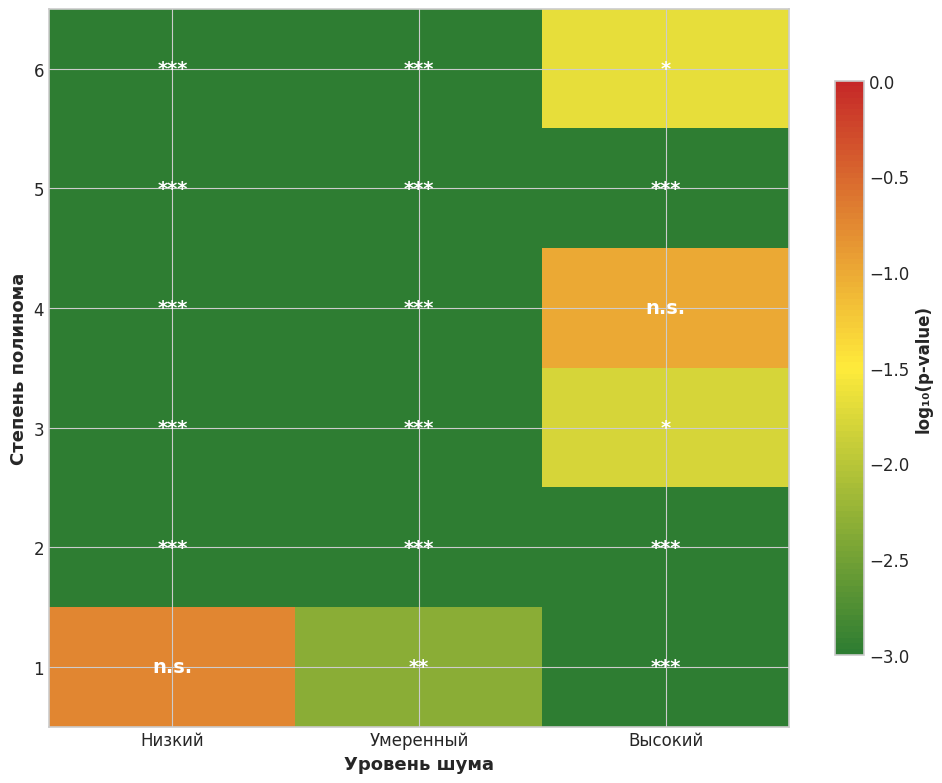


ТАБЛИЦА P-VALUE (IMSE) - ДЛЯ ВЕРИФИКАЦИИ

Степень |  Низкий   |  Умеренный  |  Высокий
-------------------------------------------------------
   6    |  < 0.001 ***  |  < 0.001 ***  |  0.0221 *    
   5    |  < 0.001 ***  |  < 0.001 ***  |  < 0.001 *** 
   4    |  < 0.001 ***  |  < 0.001 ***  |  0.1009      
   3    |  < 0.001 ***  |  < 0.001 ***  |  0.0170 *    
   2    |  < 0.001 ***  |  < 0.001 ***  |  < 0.001 *** 
   1    |  0.1782       |  0.0047 **    |  < 0.001 *** 

🔬 Выполняем t-test для IMAE...
✓ Сохранено: pvalue_heatmap_imae.png


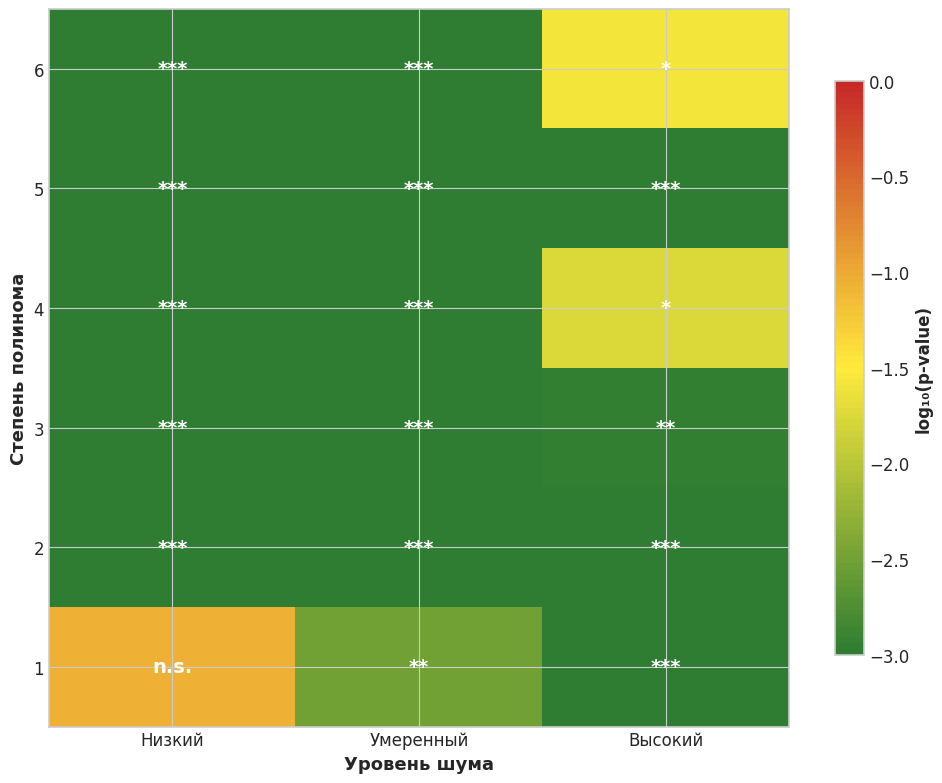


ТАБЛИЦА P-VALUE (IMAE) - ДЛЯ ВЕРИФИКАЦИИ

Степень |  Низкий   |  Умеренный  |  Высокий
-------------------------------------------------------
   6    |  < 0.001 ***  |  < 0.001 ***  |  0.0261 *    
   5    |  < 0.001 ***  |  < 0.001 ***  |  < 0.001 *** 
   4    |  < 0.001 ***  |  < 0.001 ***  |  0.0173 *    
   3    |  < 0.001 ***  |  < 0.001 ***  |  0.0011 **   
   2    |  < 0.001 ***  |  < 0.001 ***  |  < 0.001 *** 
   1    |  0.0847       |  0.0032 **    |  < 0.001 *** 

🔬 Выполняем t-test для MAXERR...
✓ Сохранено: pvalue_heatmap_maxerr.png


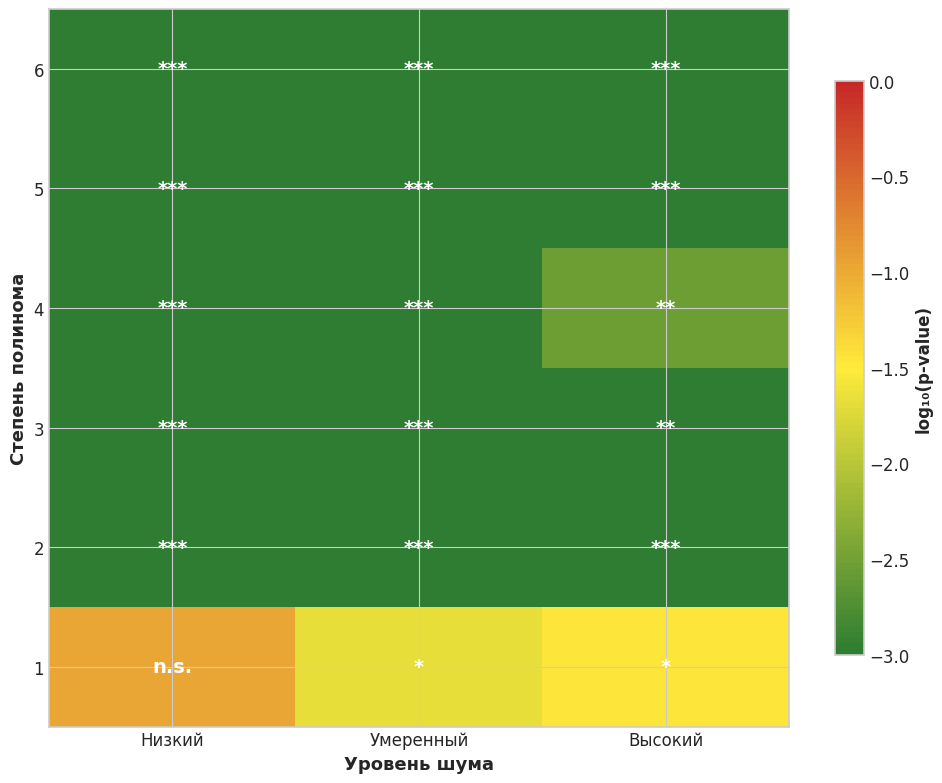


ТАБЛИЦА P-VALUE (MAXERR) - ДЛЯ ВЕРИФИКАЦИИ

Степень |  Низкий   |  Умеренный  |  Высокий
-------------------------------------------------------
   6    |  < 0.001 ***  |  < 0.001 ***  |  < 0.001 *** 
   5    |  < 0.001 ***  |  < 0.001 ***  |  < 0.001 *** 
   4    |  < 0.001 ***  |  < 0.001 ***  |  0.0029 **   
   3    |  < 0.001 ***  |  < 0.001 ***  |  0.0010 **   
   2    |  < 0.001 ***  |  < 0.001 ***  |  < 0.001 *** 
   1    |  0.1081       |  0.0223 *     |  0.0347 *    


C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1284752308.py:318: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1284752308.py:318: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1284752308.py:318: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1284752308.py:319: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('pvalue_heatmap_all_metrics.png', dpi=300, bbox_inches='tight')
C:\Users\Dima\AppData\Local\Temp\ipykernel_2576\1284752308.py:319: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('pvalue_heatmap_all_metrics.png', dpi=300, bbox_inches='tight


✓ Сохранено: pvalue_heatmap_all_metrics.png


c:\Users\Dima\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Dima\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


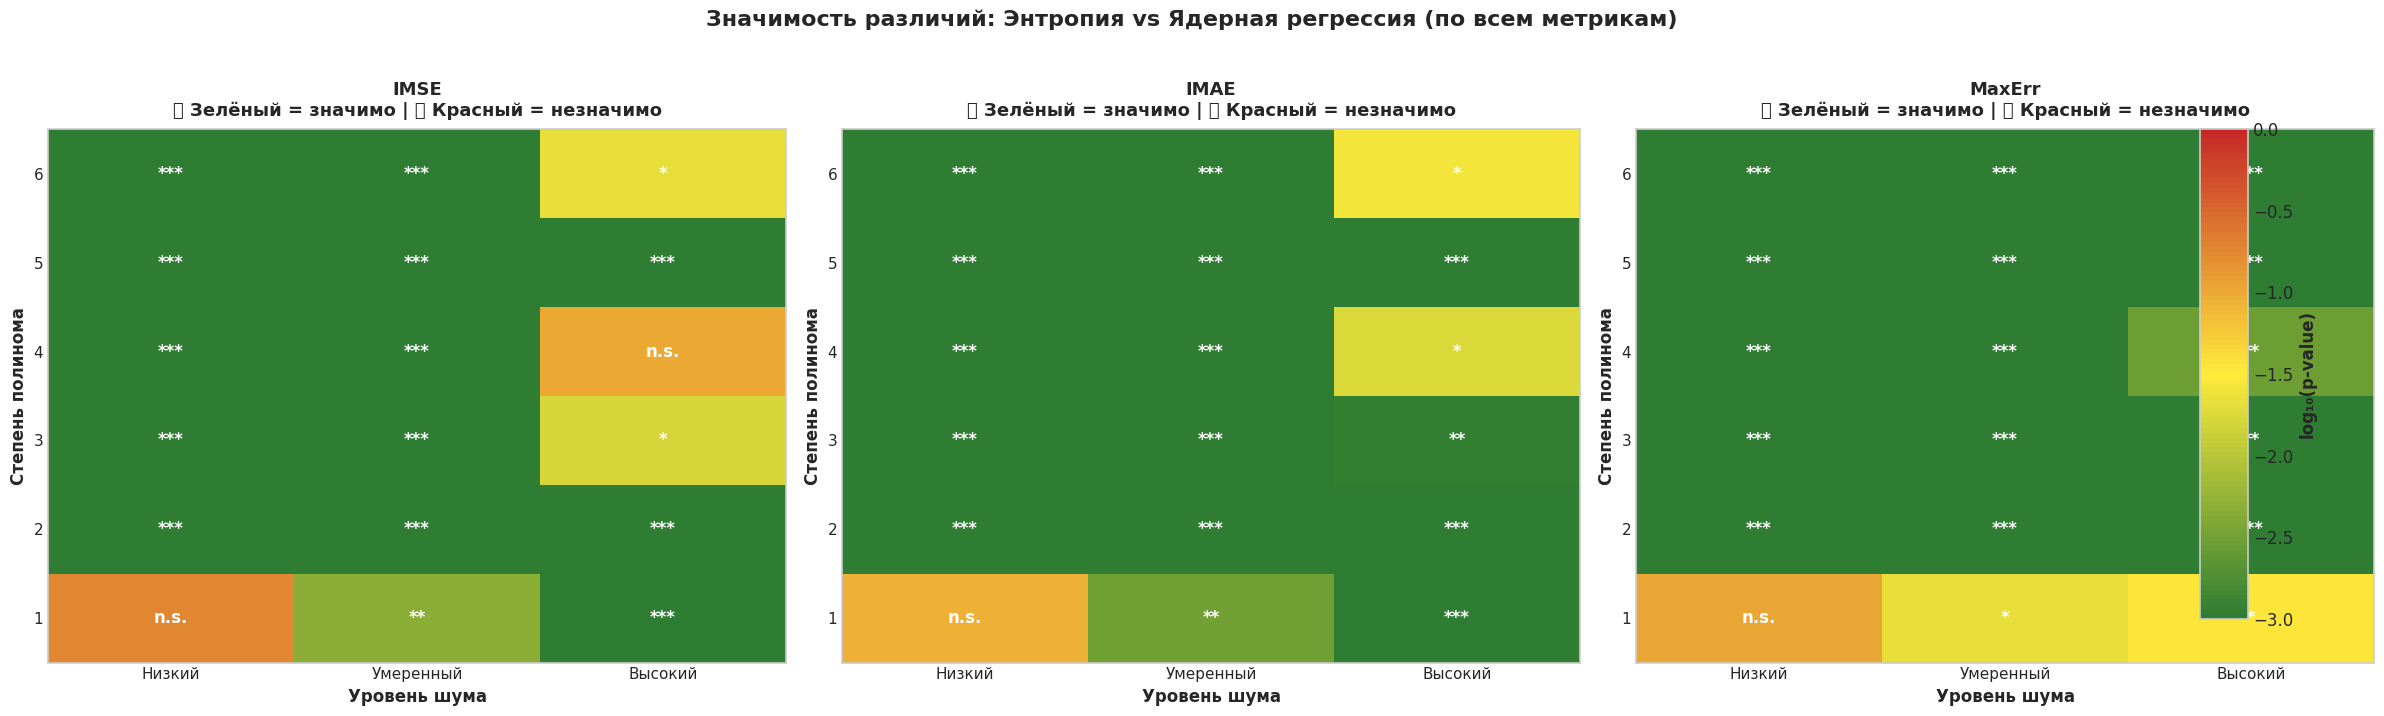


📊 Генерация тепловых карт размера эффекта (Cohen's d)...
✓ Сохранено: effect_size_heatmap_imse.png


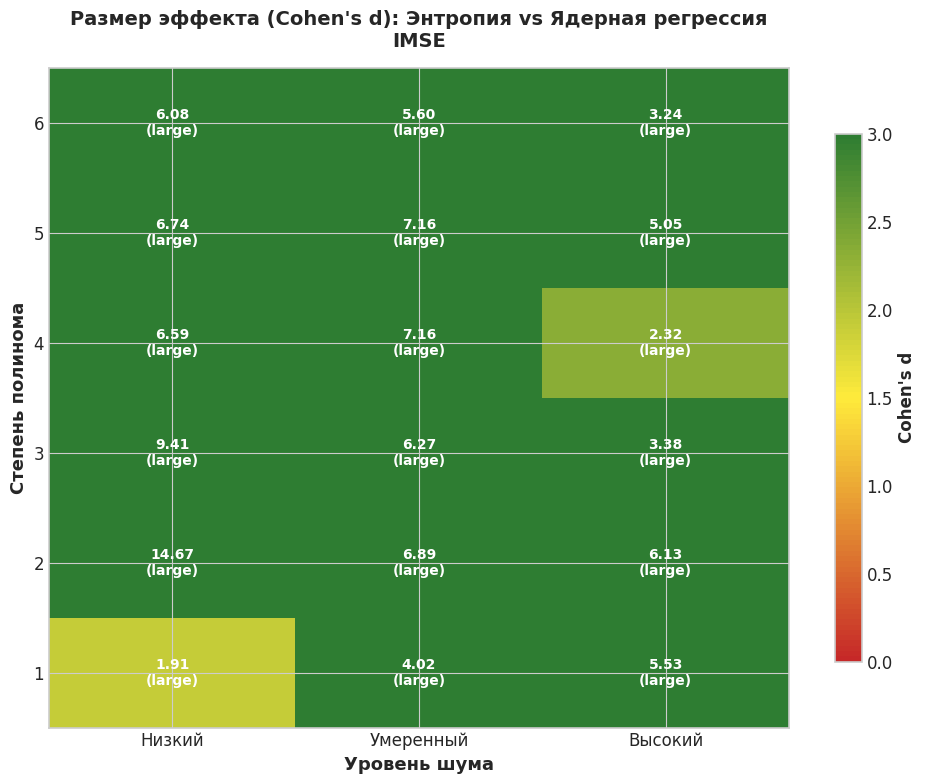

✓ Сохранено: effect_size_heatmap_imae.png


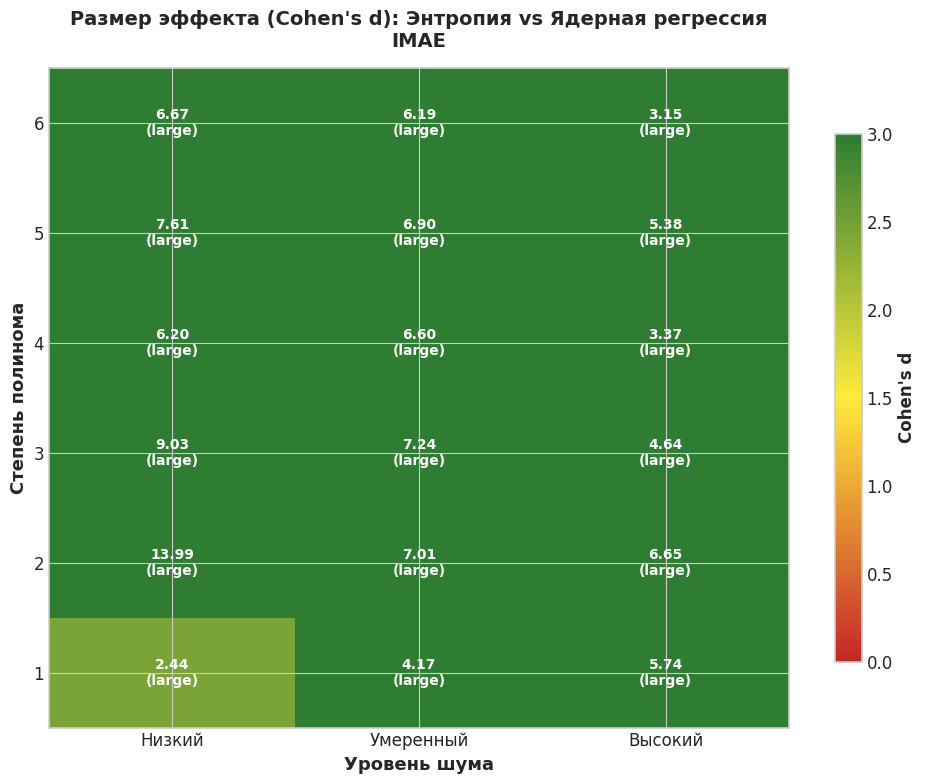

✓ Сохранено: effect_size_heatmap_maxerr.png


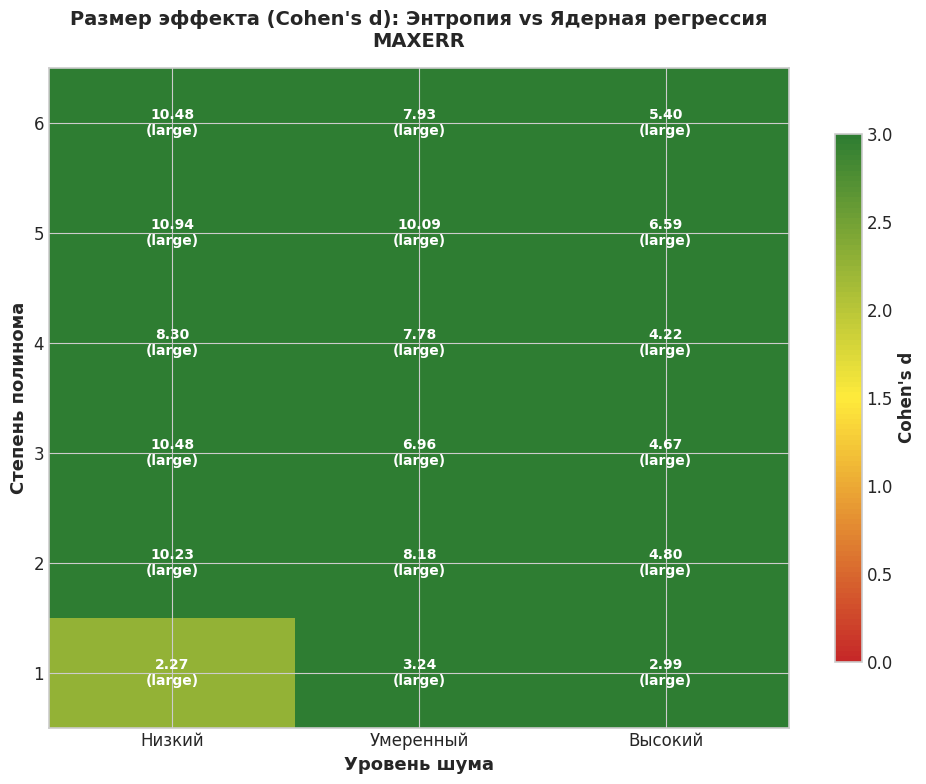


✅ ВСЕ ФАЙЛЫ СОХРАНЕНЫ:
   📁 Тепловые карты p-value:
      - pvalue_heatmap_imse.png
      - pvalue_heatmap_imae.png
      - pvalue_heatmap_maxerr.png
      - pvalue_heatmap_all_metrics.png (сводная 3 в 1)

   📁 Тепловые карты размера эффекта:
      - effect_size_heatmap_imse.png
      - effect_size_heatmap_imae.png
      - effect_size_heatmap_maxerr.png


In [12]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ: ТЕПЛОВЫЕ КАРТЫ P-VALUE ДЛЯ ВСЕХ МЕТРИК (ИСПРАВЛЕННЫЕ)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.ticker import MaxNLocator

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# =============================================================================
# ЗАГРУЗКА ДАННЫХ
# =============================================================================

df_kernel = pd.read_csv('kernel_regression_results_clean.csv')
df_entropy = pd.read_csv('entropy_aggregated_clean.csv')

# =============================================================================
# ФУНКЦИИ ДЛЯ T-TEST
# =============================================================================

def get_best_kernel_method(df_kernel, degree, noise_level, metric='imse'):
    """
    Возвращает лучший метод ядерной регрессии по критерию:
    min(metric_mean - 1.96 * metric_sem)
    """
    subset = df_kernel[(df_kernel['degree'] == degree) & 
                       (df_kernel['noise_level'] == noise_level)]
    
    subset = subset.copy()
    subset[f'{metric}_lower'] = subset[f'{metric}_mean'] - 1.96 * subset[f'{metric}_sem']
    
    best_idx = subset[f'{metric}_lower'].idxmin()
    best_row = subset.loc[best_idx]
    
    return best_row


def calculate_welch_ttest(mean1, sem1, n1, mean2, sem2, n2):
    """
    Расчёт Welch's t-test (для выборок с возможными разными дисперсиями)
    """
    from scipy import stats
    
    # T-статистика
    se_diff = np.sqrt(sem1**2 + sem2**2)
    t_stat = (mean2 - mean1) / se_diff
    
    # Степени свободы по формуле Велча-Сатертуэйта
    df = (sem1**2 + sem2**2)**2 / (sem1**4/(n1-1) + sem2**4/(n2-1))
    
    # Двусторонний p-value
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df))
    
    significant = p_value < 0.05
    highly_significant = p_value < 0.01
    
    return t_stat, p_value, df, significant, highly_significant


def perform_all_ttests(df_kernel, df_entropy, metric='imse'):
    """
    Выполняет t-test для всех комбинаций степень×шум
    """
    noise_levels = ['low', 'moderate', 'high']
    degrees = list(range(1, 7))
    
    results = []
    
    for noise in noise_levels:
        for deg in degrees:
            # Энтропия
            ent_row = df_entropy[(df_entropy['degree'] == deg) & 
                                 (df_entropy['noise_level'] == noise)]
            if len(ent_row) == 0:
                continue
            ent_row = ent_row.iloc[0]
            
            # Лучший ядерный метод
            kern_row = get_best_kernel_method(df_kernel, deg, noise, metric=metric)
            
            # T-test
            t_stat, p_value, df_welch, sig, highly_sig = calculate_welch_ttest(
                mean1=ent_row[f'{metric}_mean'],
                sem1=ent_row[f'{metric}_sem'],
                n1=ent_row['n_used'],
                mean2=kern_row[f'{metric}_mean'],
                sem2=kern_row[f'{metric}_sem'],
                n2=kern_row['n_used']
            )
            
            # Эффект (Cohen's d)
            pooled_std = np.sqrt(((ent_row[f'{metric}_sem']**2 * ent_row['n_used']) + 
                                  (kern_row[f'{metric}_sem']**2 * kern_row['n_used'])) / 
                                 (ent_row['n_used'] + kern_row['n_used'] - 2))
            cohens_d = (kern_row[f'{metric}_mean'] - ent_row[f'{metric}_mean']) / pooled_std
            
            results.append({
                'degree': deg,
                'noise_level': noise,
                'entropy_mean': ent_row[f'{metric}_mean'],
                'kernel_mean': kern_row[f'{metric}_mean'],
                'kernel_method': kern_row['method'],
                't_statistic': t_stat,
                'p_value': p_value,
                'df': df_welch,
                'significant': sig,
                'highly_significant': highly_sig,
                'cohens_d': cohens_d,
                'improvement_pct': (kern_row[f'{metric}_mean'] - ent_row[f'{metric}_mean']) / kern_row[f'{metric}_mean'] * 100
            })
    
    return pd.DataFrame(results)


# =============================================================================
# ВИЗУАЛИЗАЦИЯ: ТЕПЛОВАЯ КАРТА P-VALUE (УНИВЕРСАЛЬНАЯ ФУНКЦИЯ)
# =============================================================================

def plot_pvalue_heatmap(df_results, metric='imse', save_path=None):
    """
    Тепловая карта p-values по комбинациям степень×шум
    🟢 Зелёный = значимо (p < 0.05)
    🔴 Красный = незначимо (p >= 0.05)
    
    Args:
        df_results: DataFrame с результатами t-test
        metric: название метрики ('imse', 'imae', 'maxerr')
        save_path: путь для сохранения файла (если None, не сохраняется)
    """
    # Pivot для тепловой карты
    pivot_data = df_results.pivot(index='degree', columns='noise_level', values='p_value')
    pivot_data = pivot_data.reindex(index=[6, 5, 4, 3, 2, 1])  # Reverse order for degree
    
    # 🔧 ИСПРАВЛЕНИЕ: Явно указываем порядок столбцов по уровню шума
    pivot_data = pivot_data.reindex(columns=['low', 'moderate', 'high'])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Custom colormap: ЗЕЛЁНЫЙ (значимо) -> ЖЁЛТЫЙ (погранично) -> КРАСНЫЙ (незначимо)
    cmap = colors.LinearSegmentedColormap.from_list(
        'significance', 
        ['#2E7D32', '#FFEB3B', '#C62828'],  # Зелёный -> Жёлтый -> Красный
        N=100
    )
    
    # Тепловая карта с логарифмической шкалой
    im = ax.imshow(np.log10(pivot_data.values + 1e-10), 
                   aspect='auto', cmap=cmap, vmin=np.log10(0.001), vmax=np.log10(1.0))
    
    # Подписи значений
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            val = pivot_data.values[i, j]
            if val < 0.001:
                text = '***'
                color = 'white'
            elif val < 0.01:
                text = '**'
                color = 'white'
            elif val < 0.05:
                text = '*'
                color = 'white'
            else:
                text = 'n.s.'
                color = 'white'
            
            ax.text(j, i, text, ha='center', va='center', 
                   fontsize=14, fontweight='bold', color=color)
    
    # Оси
    ax.set_xticks(range(len(pivot_data.columns)))
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_xticklabels(['Низкий', 'Умеренный', 'Высокий'], fontsize=12)
    ax.set_yticklabels(pivot_data.index, fontsize=12)
    ax.set_xlabel('Уровень шума', fontsize=13, fontweight='bold')
    ax.set_ylabel('Степень полинома', fontsize=13, fontweight='bold')
    
    # Названия метрик для заголовка
    metric_titles = {
        'imse': 'IMSE (среднеквадратичная ошибка)',
        'imae': 'IMAE (средняя абсолютная ошибка)',
        'maxerr': 'MaxErr (максимальная ошибка)'
    }
    
    # ax.set_title(f'Значимость различий: Энтропия vs Ядерная регрессия\n{metric_titles.get(metric, metric)}\n🟢 Зелёный = значимо (p < 0.05) | 🔴 Красный = незначимо', 
    #             fontsize=14, fontweight='bold', pad=15)
    
    # Цветовая шкала
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('log₁₀(p-value)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Сохранено: {save_path}")
    
    plt.show()
    
    # 🔍 Для верификации: выводим таблицу p-value
    print(f"\n{'='*70}")
    print(f"ТАБЛИЦА P-VALUE ({metric.upper()}) - ДЛЯ ВЕРИФИКАЦИИ")
    print('='*70)
    print("\nСтепень |  Низкий   |  Умеренный  |  Высокий")
    print("-" * 55)
    for degree in pivot_data.index:
        row = pivot_data.loc[degree]
        p_low = f"{row['low']:.4f}" if row['low'] >= 0.001 else "< 0.001"
        p_mod = f"{row['moderate']:.4f}" if row['moderate'] >= 0.001 else "< 0.001"
        p_high = f"{row['high']:.4f}" if row['high'] >= 0.001 else "< 0.001"
        
        # Добавляем звёздочки
        def add_stars(p):
            if p == "< 0.001":
                return p + " ***"
            elif float(p) < 0.01:
                return p + " **"
            elif float(p) < 0.05:
                return p + " *"
            else:
                return p + "   "
        
        print(f"   {degree}    |  {add_stars(p_low):12s} |  {add_stars(p_mod):12s} |  {add_stars(p_high):12s}")
    print("=" * 70)


# =============================================================================
# ДОПОЛНИТЕЛЬНО: СВОДНАЯ ТАБЛИЦА ВСЕХ ТРЕХ МЕТРИК
# =============================================================================

def plot_all_metrics_heatmaps(df_kernel, df_entropy):
    """
    Генерирует тепловые карты p-value для всех трех метрик
    """
    metrics = ['imse', 'imae', 'maxerr']
    
    all_results = {}
    
    for metric in metrics:
        print(f"\n🔬 Выполняем t-test для {metric.upper()}...")
        df_ttest = perform_all_ttests(df_kernel, df_entropy, metric=metric)
        all_results[metric] = df_ttest
        
        # Генерируем тепловую карту
        save_path = f'pvalue_heatmap_{metric}.png'
        plot_pvalue_heatmap(df_ttest, metric=metric, save_path=save_path)
    
    # 🔥 БОНУС: Сводная тепловая карта (3 в 1)
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    
    metric_titles = {
        'imse': 'IMSE',
        'imae': 'IMAE',
        'maxerr': 'MaxErr'
    }
    
    cmap = colors.LinearSegmentedColormap.from_list(
        'significance', 
        ['#2E7D32', '#FFEB3B', '#C62828'],
        N=100
    )
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        df_results = all_results[metric]
        
        pivot_data = df_results.pivot(index='degree', columns='noise_level', values='p_value')
        pivot_data = pivot_data.reindex(index=[6, 5, 4, 3, 2, 1])
        pivot_data = pivot_data.reindex(columns=['low', 'moderate', 'high'])
        
        im = ax.imshow(np.log10(pivot_data.values + 1e-10), 
                       aspect='auto', cmap=cmap, vmin=np.log10(0.001), vmax=np.log10(1.0))
        
        # Подписи значений
        for i in range(len(pivot_data.index)):
            for j in range(len(pivot_data.columns)):
                val = pivot_data.values[i, j]
                if val < 0.001:
                    text = '***'
                    color = 'white'
                elif val < 0.01:
                    text = '**'
                    color = 'white'
                elif val < 0.05:
                    text = '*'
                    color = 'white'
                else:
                    text = 'n.s.'
                    color = 'white'
                
                ax.text(j, i, text, ha='center', va='center', 
                       fontsize=12, fontweight='bold', color=color)
        
        ax.set_xticks(range(len(pivot_data.columns)))
        ax.set_yticks(range(len(pivot_data.index)))
        ax.set_xticklabels(['Низкий', 'Умеренный', 'Высокий'], fontsize=11)
        ax.set_yticklabels(pivot_data.index, fontsize=11)
        ax.set_xlabel('Уровень шума', fontsize=12, fontweight='bold')
        ax.set_ylabel('Степень полинома', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric_titles[metric]}\n🟢 Зелёный = значимо | 🔴 Красный = незначимо', 
                    fontsize=13, fontweight='bold', pad=10)
        ax.grid(False)
    
    # Общая цветовая шкала
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('log₁₀(p-value)', fontsize=12, fontweight='bold')
    
    plt.suptitle('Значимость различий: Энтропия vs Ядерная регрессия (по всем метрикам)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('pvalue_heatmap_all_metrics.png', dpi=300, bbox_inches='tight')
    print("\n✓ Сохранено: pvalue_heatmap_all_metrics.png")
    plt.show()
    
    return all_results


# =============================================================================
# ДОПОЛНИТЕЛЬНО: ТЕПЛОВАЯ КАРТА РАЗМЕРА ЭФФЕКТА (COHEN'S D)
# =============================================================================

def plot_effect_size_heatmap(df_results, metric='imse', save_path=None):
    """
    Тепловая карта размера эффекта (Cohen's d)
    🟢 Тёмно-зелёный = большой эффект, 🔴 Красный = малый эффект
    """
    pivot_data = df_results.pivot(index='degree', columns='noise_level', values='cohens_d')
    pivot_data = pivot_data.reindex(index=[6, 5, 4, 3, 2, 1])
    pivot_data = pivot_data.reindex(columns=['low', 'moderate', 'high'])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Colormap: красный (малый) -> жёлтый (средний) -> зелёный (большой)
    cmap = colors.LinearSegmentedColormap.from_list(
        'effect_size', 
        ['#C62828', '#FFEB3B', '#2E7D32'],
        N=100
    )
    
    im = ax.imshow(pivot_data.values, aspect='auto', cmap=cmap, vmin=0, vmax=3)
    
    # Подписи значений
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            val = pivot_data.values[i, j]
            if val >= 0.8:
                text = f'{val:.2f}\n(large)'
            elif val >= 0.5:
                text = f'{val:.2f}\n(medium)'
            elif val >= 0.2:
                text = f'{val:.2f}\n(small)'
            else:
                text = f'{val:.2f}\n(negl.)'
            
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, text, ha='center', va='center', 
                   fontsize=10, fontweight='bold', color=color)
    
    # Оси
    ax.set_xticks(range(len(pivot_data.columns)))
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_xticklabels(['Низкий', 'Умеренный', 'Высокий'], fontsize=12)
    ax.set_yticklabels(pivot_data.index, fontsize=12)
    ax.set_xlabel('Уровень шума', fontsize=13, fontweight='bold')
    ax.set_ylabel('Степень полинома', fontsize=13, fontweight='bold')
    ax.set_title(f'Размер эффекта (Cohen\'s d): Энтропия vs Ядерная регрессия\n{metric.upper()}', 
                fontsize=14, fontweight='bold', pad=15)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Cohen's d", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Сохранено: {save_path}")
    
    plt.show()


# =============================================================================
# ЗАПУСК АНАЛИЗА
# =============================================================================

if __name__ == '__main__':
    print("🔬 Запуск статистического анализа для всех метрик...\n")
    
    # Генерируем все тепловые карты
    all_results = plot_all_metrics_heatmaps(df_kernel, df_entropy)
    
    # Дополнительно: тепловые карты размера эффекта для каждой метрики
    print("\n📊 Генерация тепловых карт размера эффекта (Cohen's d)...")
    for metric in ['imse', 'imae', 'maxerr']:
        save_path = f'effect_size_heatmap_{metric}.png'
        plot_effect_size_heatmap(all_results[metric], metric=metric, save_path=save_path)
    
    print("\n" + "=" * 70)
    print("✅ ВСЕ ФАЙЛЫ СОХРАНЕНЫ:")
    print("=" * 70)
    print("   📁 Тепловые карты p-value:")
    print("      - pvalue_heatmap_imse.png")
    print("      - pvalue_heatmap_imae.png")
    print("      - pvalue_heatmap_maxerr.png")
    print("      - pvalue_heatmap_all_metrics.png (сводная 3 в 1)")
    print("\n   📁 Тепловые карты размера эффекта:")
    print("      - effect_size_heatmap_imse.png")
    print("      - effect_size_heatmap_imae.png")
    print("      - effect_size_heatmap_maxerr.png")
    print("=" * 70)
